# Balanced Oracle Test

# Deutsch-Jozsa: Balanced Oracle Testing

**Objective:** Implement and verify a Balanced Oracle within the Deutsch-Jozsa algorithm framework.

**Theory:**
A Balanced Oracle is a black-box function that outputs `0` for exactly half of its inputs, and `1` for the other half. 

When we pass a uniform superposition through a Balanced Oracle and apply our final set of Hadamard gates, the **Phase Kickback** causes destructive interference for the $|00...0\rangle$ state. Because that state is completely canceled out, a successfully implemented Balanced Oracle will **never** result in a measurement of all zeros.

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from IPython.display import display

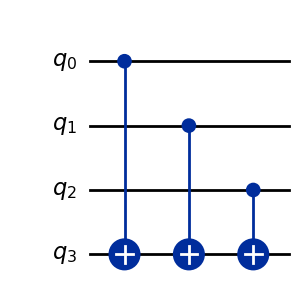

In [2]:
def build_balanced_oracle(n: int) -> QuantumCircuit:
    """
    Builds an n-qubit balanced oracle.
    We apply CNOT gates controlled by each input qubit, targeting the ancilla.
    This guarantees exactly half the input states will flip the ancilla.
    """
    oracle = QuantumCircuit(n + 1, name="Balanced Oracle")
    
    # Optional: We can wrap the CNOTs in X gates to change which specific 
    # states output 1 vs 0, but CNOTs alone are sufficient for a balanced state.
    for qubit in range(n):
        oracle.cx(qubit, n)
        
    return oracle

# Visualize a 3-qubit balanced oracle
n_qubits = 3
balanced_oracle = build_balanced_oracle(n_qubits)
display(balanced_oracle.draw('mpl'))

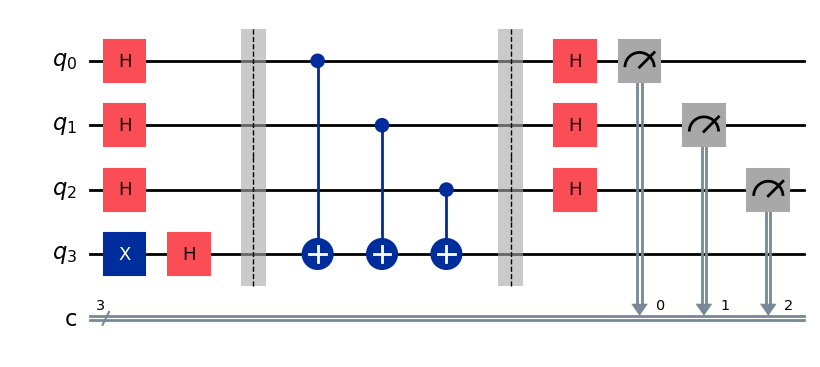

In [3]:
def deutsch_jozsa_circuit(oracle: QuantumCircuit, n: int) -> QuantumCircuit:
    """Wraps an oracle in the Deutsch-Jozsa Hadamard sandwich."""
    qc = QuantumCircuit(n + 1, n)
    
    # 1. Prepare the ancilla (output) qubit in the |1> state
    qc.x(n)
    
    # 2. Apply H-gates to all qubits (inputs enter superposition, ancilla enters |-> state)
    qc.h(range(n + 1))
    qc.barrier()
    
    # 3. Append the Oracle
    qc.compose(oracle, inplace=True)
    qc.barrier()
    
    # 4. Apply H-gates to the input register to cause interference
    qc.h(range(n))
    
    # 5. Measure the input register
    qc.measure(range(n), range(n))
    
    return qc

# Build the full circuit using our balanced oracle
dj_balanced_circuit = deutsch_jozsa_circuit(balanced_oracle, n_qubits)
display(dj_balanced_circuit.draw('mpl'))

Balanced Oracle Output: {'111': 1024}


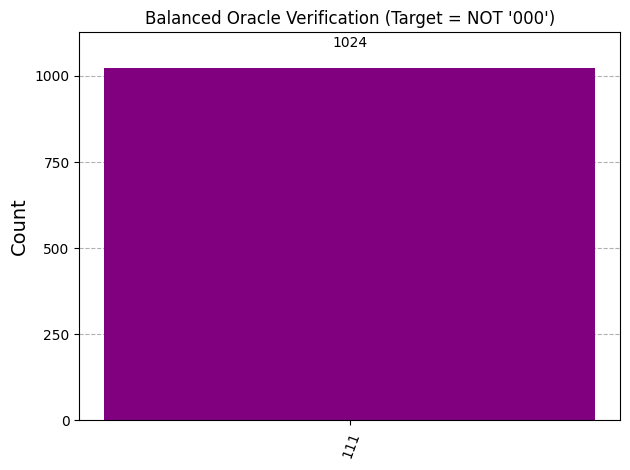

In [4]:
# Initialize the modern V2 Sampler
sampler = StatevectorSampler()

# Execute the circuit over 1024 shots
job = sampler.run([dj_balanced_circuit], shots=1024)
pub_result = job.result()[0]

# Extract counts from the classical register
counts = pub_result.data.c.get_counts()

print(f"Balanced Oracle Output: {counts}")

# Verification: The result MUST NOT contain '000'. 
# Depending on the specific balanced oracle construction, it will be a different state, often '111'.
display(plot_histogram(counts, title="Balanced Oracle Verification (Target = NOT '000')", color='purple'))